# Validate clustered parameter datasets

This notebook checks the five generated `c_i=(theta_i, Gamma_i)` datasets.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

ROOT = Path('.')
OUT = ROOT / 'outputs'
DATA = OUT / 'datasets'
metrics = pd.read_csv(OUT / 'metrics_summary.csv')
metrics

,dataset_id,scenario,n_clusters,cluster_sizes,contraction_factor,overlap_ratio,pairwise_overlap_ratios,full_pairwise_overlap,overlap_graph_connected,silhouette_score,davies_bouldin_index,minimum_gamma_eigenvalue,maximum_spd_shift
0,params_K1_homogeneous,homogeneous,1,10,1.00,NaN,{},NaN,NaN,NaN,NaN,1.000000,0.172740
1,params_K2_separated,separated,2,5/5,1.00,0.131813,"{""0-1"": 0.13181333815194438}",False,False,0.931489,0.097262,1.000000,0.177760
2,params_K2_overlapping,overlapping,2,5/5,0.08,1.174500,"{""0-1"": 1.1745003971012118}",True,True,0.401386,0.900634,1.850126,0.000000
3,params_K3_separated,separated,3,4/3/3,1.00,0.130190,"{""0-1"": 0.10865999356676559, ""0-2"": 0.13019045...",False,False,0.923182,0.113667,1.000000,0.034206
4,params_K3_overlapping,overlapping,3,4/3/3,0.08,1.809964,"{""0-1"": 1.231117797600119, ""0-2"": 1.6287648223...",True,True,0.375784,1.398465,2.035298,0.000000


## Load one dataset record

In [2]:
def load_record(path):
    with open(path, 'r') as f:
        return json.loads(f.readline())

record = load_record(DATA / 'params_K3_overlapping.jsonl')
print(record['dataset_id'])
print('labels:', record['labels'])
print('pairwise OR:', record['cluster_metrics']['pairwise_overlap_ratios'])

params_K3_overlapping
labels: [0, 0, 0, 0, 1, 1, 1, 2, 2, 2]
pairwise OR: {'0-1': 1.231117797600119, '0-2': 1.628764822315515, '1-2': 1.8099635909116791}


## SPD validation

In [3]:
rows = []
for path in sorted(DATA.glob('params_*.jsonl')):
    r = load_record(path)
    G = np.array(r['gamma_list'])
    eig_min = min(np.linalg.eigvalsh(Gi).min() for Gi in G)
    sym_err = np.max(np.abs(G - np.swapaxes(G, 1, 2)))
    rows.append({'dataset': r['dataset_id'], 'min eigenvalue': eig_min, 'max symmetry error': sym_err})
pd.DataFrame(rows)

,dataset,min eigenvalue,max symmetry error
0,params_K1_homogeneous,1.000000,0.0
1,params_K2_overlapping,1.850126,0.0
2,params_K2_separated,1.000000,0.0
3,params_K3_overlapping,2.035298,0.0
4,params_K3_separated,1.000000,0.0


## Validation figures

Figures are saved under `outputs/figures/`.

params_K2_separated_mds.png


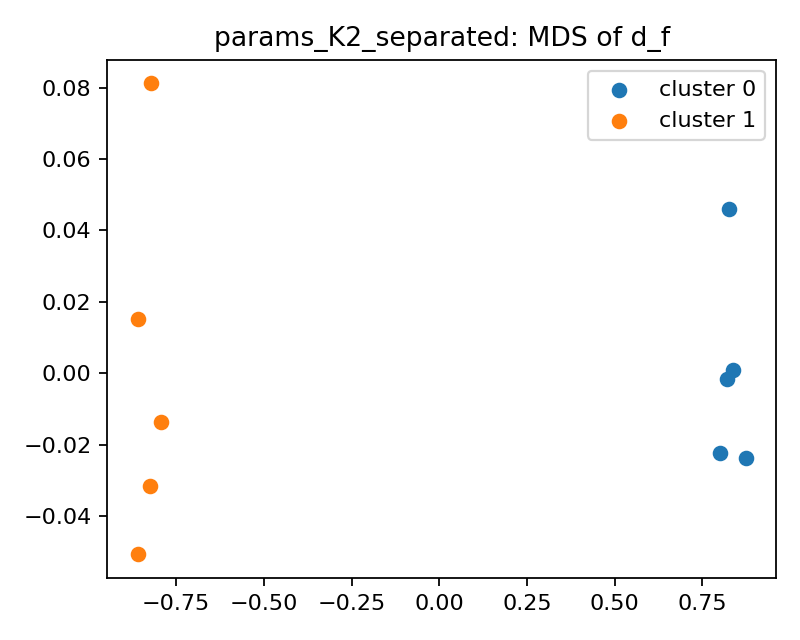

params_K2_overlapping_mds.png


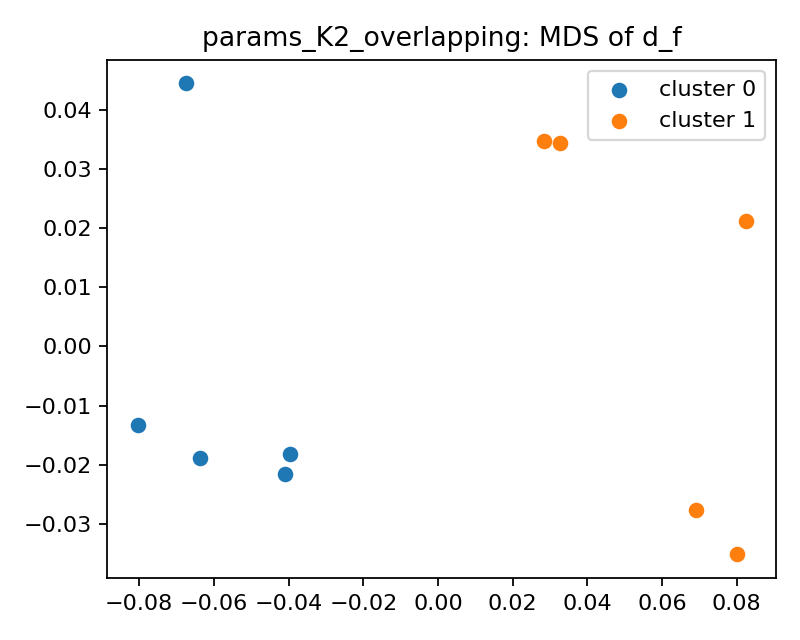

params_K3_separated_mds.png


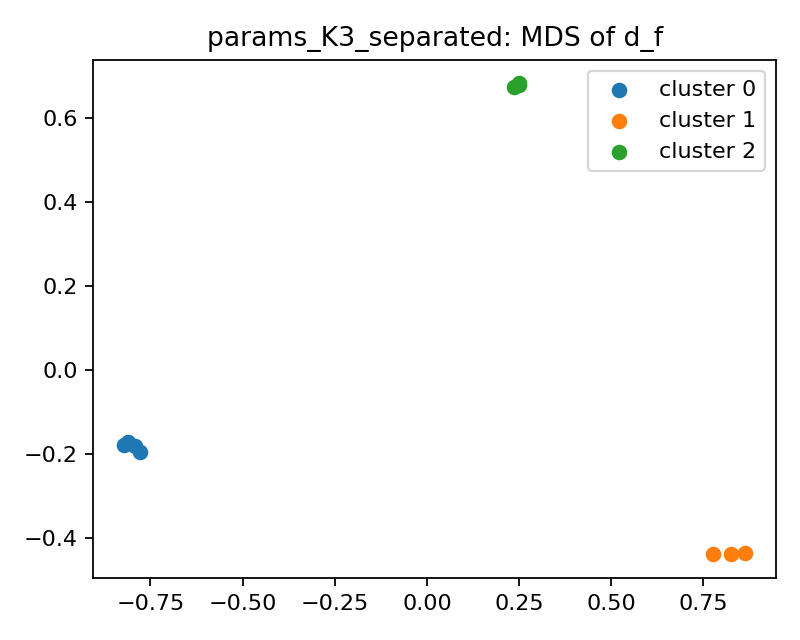

params_K3_overlapping_mds.png


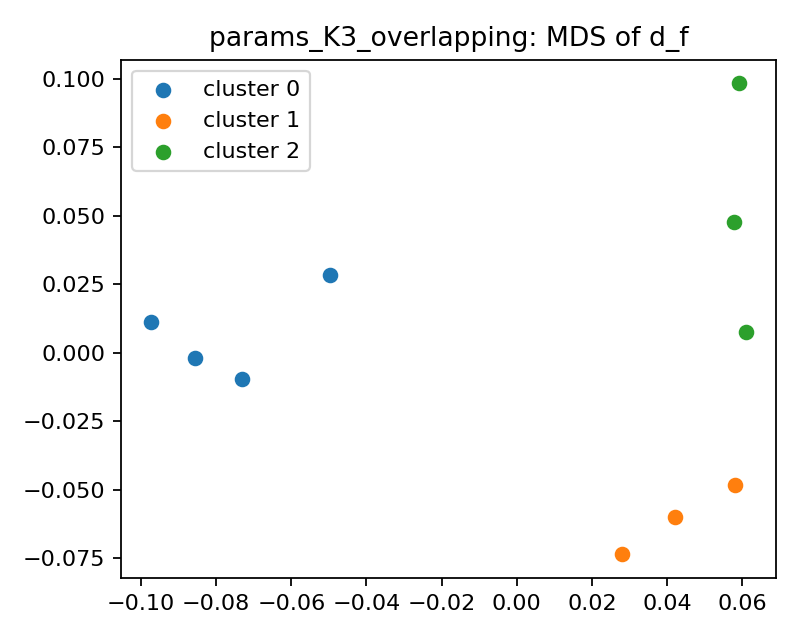

In [4]:
from IPython.display import Image, display
for name in ['params_K2_separated_mds.png', 'params_K2_overlapping_mds.png', 'params_K3_separated_mds.png', 'params_K3_overlapping_mds.png']:
    print(name)
    display(Image(filename=str(OUT / 'figures' / name)))